In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df_clean = pd.read_csv('../data/cleaned_retail.csv')
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [3]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [4]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

In [5]:
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]) 
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

In [6]:
rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

In [7]:
def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Key Accounts'
    elif f >= 4:
        return 'Stable Core'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [8]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,12347,2,7,4310.00,5,5,5,15,Key Accounts
1,12348,75,4,1797.24,2,4,4,10,Stable Core
2,12349,19,1,1757.55,4,1,4,9,Promising
3,12350,310,1,334.40,1,1,2,4,Lost
4,12352,36,8,2506.04,3,5,5,13,Stable Core


In [9]:
rfm['Segment'].value_counts()

Segment
Needs Attention    1199
Key Accounts        962
Stable Core         772
Promising           671
At Risk             369
Lost                363
Name: count, dtype: int64

In [10]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4336 entries, 0 to 4335
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CustomerID  4336 non-null   int64   
 1   Recency     4336 non-null   int64   
 2   Frequency   4336 non-null   int64   
 3   Monetary    4336 non-null   float64 
 4   R           4336 non-null   category
 5   F           4336 non-null   category
 6   M           4336 non-null   category
 7   RFM_Score   4336 non-null   int64   
 8   Segment     4336 non-null   object  
dtypes: category(3), float64(1), int64(4), object(1)
memory usage: 216.7+ KB


In [11]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Segment,,,
At Risk,164.7,2.3,998.4
Key Accounts,12.9,11.1,6023.3
Lost,278.6,1.0,332.9
Needs Attention,121.5,1.6,597.6
Promising,36.9,1.2,465.4
Stable Core,73.3,5.0,1687.3


In [12]:
rfm.to_csv('../data/rfm_segments.csv', index=False)

/tmp/ipykernel_8749/4130952629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


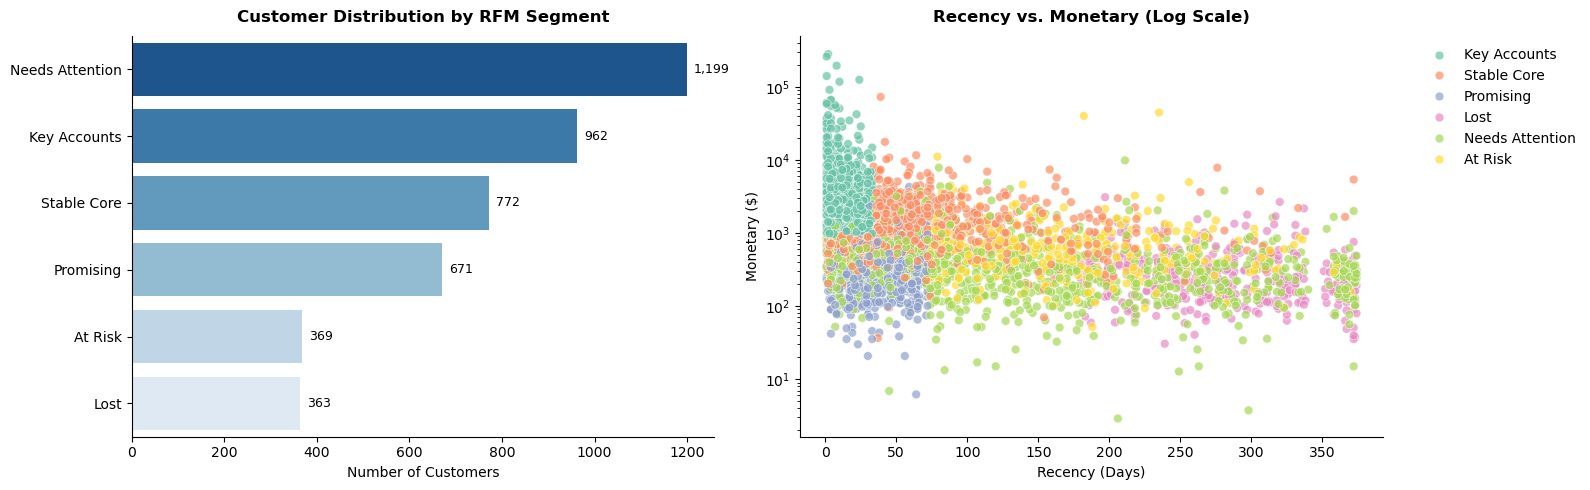

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

sns.barplot(
    data=segment_counts, 
    x='Count', 
    y='Segment', 
    palette='Blues_r', 
    ax=axes[0]
)
axes[0].set_title('Customer Distribution by RFM Segment', fontsize=12, pad=10, weight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('')

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Segment', 
    palette='Set2', 
    alpha=0.7, 
    s=40,
    ax=axes[1]
)
axes[1].set_yscale('log') 
axes[1].set_title('Recency vs. Monetary (Log Scale)', fontsize=12, pad=10, weight='bold')
axes[1].set_xlabel('Recency (Days)')
axes[1].set_ylabel('Monetary ($)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

### Insight
The RFM segmentation of 4,336 unique customers demonstrates a robust commercial core, with 'Key Accounts' and 'Stable Core' segments driving 40% of the active customer base and exhibiting exceptional metrics ('Key Accounts' average 11.1 orders and $6,023 in revenue). However, 'Needs Attention' represents the single largest group (1,199 clients), indicating a critical window for lifecycle nurturing before engagement drops. Furthermore, the 'At Risk' cohort consists of previously valuable repeat buyers (2.3 orders, $998 revenue) who have been inactive for over 5 months. Strategic priority must focus on automated win-back triggers for the At Risk segment and cross-sell onboarding workflows for Promising / Needs Attention buyers.